In [10]:
import numpy as np
import matplotlib.pyplot as plt

## Problem 3

In [25]:
def my_lu(A,pivoting=None):
    
    """
    This function factors A = LU (if pivoting=None; default) or PA = LU (if pivoting='partial')
    INPUT:
        matrix A
    OUTPUT:
        permutation vector p (if pivoting == 'partial')
        lower triangular factor L
        upper triangular factor U
    """
    
    n,m = A.shape # size of matrix A
    if m!=n: # check if A is square
        print('WARNING: A must be a square matrix') # print a warning massage
        return  
    
    # initialize factors L and U
    U = A.copy()
    L = np.identity(n)
    
    # initialize permutation vector p = [0,1,...,n-1]
    if pivoting == 'partial':
        p = np.arange(n)
    
    # GAUSSIAN ELIMINATION 
    for i in range(n):  # loop over columns 1,...,n (first loop)
        if pivoting=='partial':
            # Find the entry with largest absolute value
            row2swap = i + np.argmax(np.abs(U[i:n,i]))
            # swap rows of U
            U[[row2swap,i],i:n] = U[[i,row2swap],i:n]
            # swap multipliers
            L[[row2swap,i],0:i] = L[[i,row2swap],0:i] 
            # update permutation vector p
            p[[row2swap,i]]=p[[i,row2swap]]
        # multipliers 
        L[i+1:n,i] = U[i+1:n,i]/U[i,i] 
        # update U
        U[i+1:n,i] = 0 
        U[i+1:n,i+1:n] = U[i+1:n,i+1:n] - np.outer(L[i+1:n,i],U[i,i+1:n]) # update U
    
    if pivoting=='partial':
        return L,U,p
    else:
        return L,U

In [26]:
def my_solve(A,b,pivoting=None):
    'this function solves Ax=b'

    # size of the problem
    n = len(b)
    
    # initialize vectors x and y
    y = np.zeros(n)
    x = np.zeros(n)

    # compute LU factorization
    if pivoting==None:
        L,U = my_lu(A,pivoting)
        bp=b
        
    else:
        L,U,p = my_lu(A,pivoting)
        #permute b
        bp= b[p]

    # solve Ly = b
    for i in range(n):
        y[i] = bp[i] - L[i,0:i].dot(y[0:i])

    # solve Ux = y
    for i in reversed(range(n)): # i = n,...,1
        x[i] = (y[i] - U[i,i+1:n].dot(x[i+1:n]))/U[i,i]

    return x

In [27]:
A = np.array([[1,1,1],[2,2+10e-15,5],[4,6,8]])
b = np.array([1,0,0])

In [28]:
my_solve(A,b,pivoting=None)

array([ 2.31884058, -0.65217391, -0.66666667])

In [29]:
my_solve(A,b,pivoting='partial')

array([ 2.33333333, -0.66666667, -0.66666667])

Gaussian elimination includes cancellation in the calculation of $2+\epsilon - 2$

****
## Problem 4

part b)

In [2]:
def inverse(A):
    m,n = A.shape
    inv = np.zeros(m,n)
    
    I = np.eye(m)
    
    for i in range(m):
        inv[:,i] = np.linalg.solve(A,I[:,i])
        
    return inv

## Problem 5

In [3]:
def cramer(A,b):
    x = np.zeros(len(b))
    d_A = np.linalg.det(A)
    for i in range(len(b)):
        Ai = A.copy()
        Ai[:,i]=b
        x[i] = np.linalg.det(Ai)
        
    return x/d_A

In [4]:
A = np.random.randn(3,3)
b = np.random.randn(3)

In [5]:
x = np.linalg.solve(A,b)
x

array([ 4.04280696, -0.22688393,  0.31254472])

In [6]:
cramer(A,b)

array([ 4.04280696, -0.22688393,  0.31254472])

****
## Problem 6

I use the function from problem 8 to make invertible matrices. It's not important that they have integer entries though, but it is important that they are invertible!

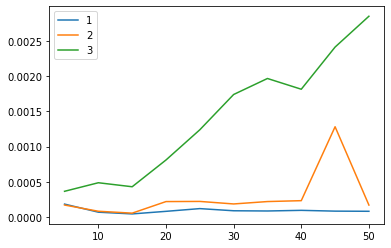

In [24]:
time1 = []
time2 = []
time3 = []

n_list = [5,10,15,20,25,30,35,40,45,50]

import time

for n in n_list:
    A = np.random.randn(n,n) # pray this is invertible- it usually should be for dimension reasons
    b = np.random.randint(128,size=n)
    
    start = time.time()
    x=np.linalg.solve(A,b)
    end = time.time()
    time1.append(end-start)
    
    start = time.time()
    x=np.linalg.inv(A).dot(b)
    end = time.time()
    time2.append(end-start)
    
    start = time.time()
    x=cramer(A,b)
    end = time.time()
    time3.append(end-start)
    
plt.plot(n_list,time1, label = '1')
plt.plot(n_list,time2, label = '2')
plt.plot(n_list,time3, label = '3')
plt.legend()

Method 1 is fastest. Finding an LU factorization has been shown to be faster than finding inverses (but both are $O(n^3)$) so we'd expect it to be slightly faster. Cramer's rule involves calculating determinants, which is at least $O(n^n)$, as there are $n!$ permutations to check. In fact, I think it is $O(n^{n-1}$, as each permutation involves at least $n$ oeprations.

****
## Problem 7

In [54]:
def my_ul(A):
    
    n,m = A.shape # size of matrix A
    if m!=n: # check if A is square
        print('WARNING: A must be a square matrix') # print a warning massage
        return  
    
    # initialize factors L and U
    U = A.copy()
    L = np.identity(n)
    
    # GAUSSIAN ELIMINATION 
    for j in range(n):  # loop over rows n,...,0 (first loop)
        i = n-j-1
        # multipliers 
        L[i,0:i] = U[i,0:i]/U[i,i] 
        # update U
        U[i, 0:i] = 0 
        U[0:i,0:i] = U[0:i,0:i] - np.outer(U[0:i,i],L[i,0:i]) # update U
        
    return U,L

In [64]:
A = np.array([[1,5,3],[4,5,2],[7,8,10]])

U,L = my_ul(A*1.0)

In [65]:
A

array([[ 1,  5,  3],
       [ 4,  5,  2],
       [ 7,  8, 10]])

In [66]:
L

array([[1.        , 0.        , 0.        ],
       [0.76470588, 1.        , 0.        ],
       [0.7       , 0.8       , 1.        ]])

In [67]:
U

array([[-3.08823529,  2.6       ,  3.        ],
       [ 0.        ,  3.4       ,  2.        ],
       [ 0.        ,  0.        , 10.        ]])

In [68]:
U.dot(L)

array([[ 1.,  5.,  3.],
       [ 4.,  5.,  2.],
       [ 7.,  8., 10.]])

****
## Problem 8

In [14]:
def make_inv_int(n, maxintseed=128):
    x = np.random.randint(maxintseed,size=(n,n)) # entries are random integers from 0 to maxintseed
    for i in range(n):
        x[i,i] = 1 # put zeros on diagonal
    L = np.tril(x) # split off lower triangular part
    U = np.triu(x) # split off upper traingular part
    
    return L.dot(U) #matrix A = LU will have integer entries and be invertible